In [7]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px
import plotly.graph_objects as go

sns.set_theme(style='whitegrid')
plt.rcParams['figure.figsize'] = (10, 5)
print('Libraries loaded!')

Libraries loaded!


In [8]:
df = pd.read_csv('crime_incidents.csv')
print(f'Shape: {df.shape[0]} rows x {df.shape[1]} columns')
df.head()

Shape: 29303 rows x 25 columns


,X,Y,CCN,REPORT_DAT,START_DATE,END_DATE,BLOCK,OFFENSE,METHOD,SHIFT,...,BLOCK_GROUP,CENSUS_TRACT,VOTING_PRECINCT,BID,XBLOCK,YBLOCK,LATITUDE,LONGITUDE,OBJECTID,OCTO_RECORD_ID
0,406321.09,137111.49,24137087,2024/09/05 20:27:50+00,2024/09/05 18:13:00+00,2024/09/05 19:55:00+00,5067 - 5099 BLOCK OF JAY STREET NE,MOTOR VEHICLE THEFT,OTHERS,EVENING,...,007809 1,7809.0,Precinct 94,NaN,406321.09,137111.49,38.901835,-76.927127,931429856,NaN
1,403638.94,135772.42,24421597,2024/05/08 12:22:39+00,2024/04/28 01:00:00+00,2024/04/28 01:30:00+00,2300 - 3955 BLOCK OF EAST CAPITOL STREET,THEFT/OTHER,OTHERS,DAY,...,006804 1,6804.0,Precinct 80,NaN,403638.94,135772.42,38.889787,-76.958056,931429858,NaN
2,400366.22,132181.42,24048718,2024/04/01 20:11:32+00,2024/03/01 17:00:00+00,2024/03/28 20:00:00+00,2632 - 2663 BLOCK OF MARTIN LUTHER KING JR AVE...,THEFT/OTHER,OTHERS,EVENING,...,007401 2,7401.0,Precinct 119,ANACOSTIA,400366.22,132181.42,38.857445,-76.995781,931429859,NaN
3,397874.16,139955.89,24008097,2024/01/17 06:03:40+00,2024/01/17 05:05:00+00,2024/01/17 05:57:00+00,700 - 999 BLOCK OF HOBART PLACE NW,ROBBERY,GUN,MIDNIGHT,...,003100 1,3100.0,Precinct 37,NaN,397874.16,139955.89,38.927478,-77.024517,931429862,NaN
4,394784.25,137339.73,24421636,2024/05/09 13:22:10+00,2024/04/29 13:00:00+00,2024/04/30 13:30:00+00,1000 - 1099 BLOCK OF THOMAS JEFFERSON STREET NW,THEFT/OTHER,OTHERS,DAY,...,000102 3,102.0,Precinct 5,GEORGETOWN,394784.25,137339.73,38.903898,-77.060131,931429864,NaN


In [9]:
print("Missing values per column:")
print(df.isnull().sum())
print(f"\nDuplicate rows: {df.duplicated().sum()}")

Missing values per column:
X                           0
Y                           0
CCN                         0
REPORT_DAT                  0
START_DATE                  5
END_DATE                 2095
BLOCK                       0
OFFENSE                     0
METHOD                      0
SHIFT                       0
WARD                        4
ANC                         4
DISTRICT                  728
PSA                       454
NEIGHBORHOOD_CLUSTER        4
BLOCK_GROUP                13
CENSUS_TRACT               13
VOTING_PRECINCT             4
BID                     23884
XBLOCK                      0
YBLOCK                      0
LATITUDE                    0
LONGITUDE                   0
OBJECTID                    0
OCTO_RECORD_ID          29303
dtype: int64

Duplicate rows: 0


In [10]:
# Remove duplicates
df = df.drop_duplicates()

# Drop rows missing key columns
df = df.dropna(subset=['OFFENSE', 'WARD', 'SHIFT', 'METHOD', 'REPORT_DAT'])

# Convert dates and extract time info
df['REPORT_DAT'] = pd.to_datetime(df['REPORT_DAT'], errors='coerce')
df['MONTH'] = df['REPORT_DAT'].dt.month
df['DAY_OF_WEEK'] = df['REPORT_DAT'].dt.day_name()
df['HOUR'] = df['REPORT_DAT'].dt.hour

print(f"Clean dataset: {df.shape[0]} rows x {df.shape[1]} columns")

Clean dataset: 29299 rows x 28 columns


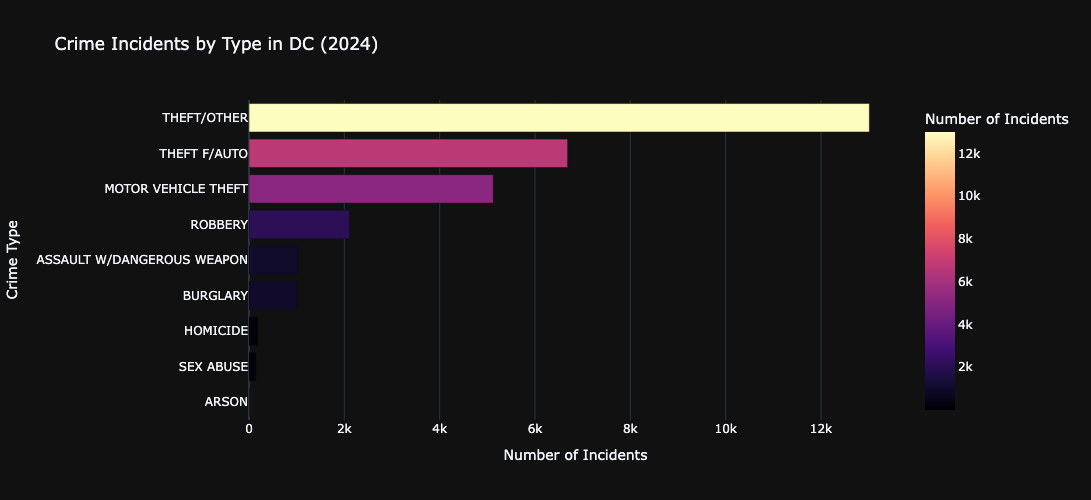

In [11]:
offense_counts = df['OFFENSE'].value_counts().reset_index()
offense_counts.columns = ['Offense', 'Count']

fig1 = px.bar(
    offense_counts,
    x='Count',
    y='Offense',
    orientation='h',
    title='Crime Incidents by Type in DC (2024)',
    color='Count',
    color_continuous_scale='Magma',
    labels={'Count': 'Number of Incidents', 'Offense': 'Crime Type'},
    template='plotly_dark'
)
fig1.update_layout(yaxis={'categoryorder': 'total ascending'}, height=500)
fig1.show()

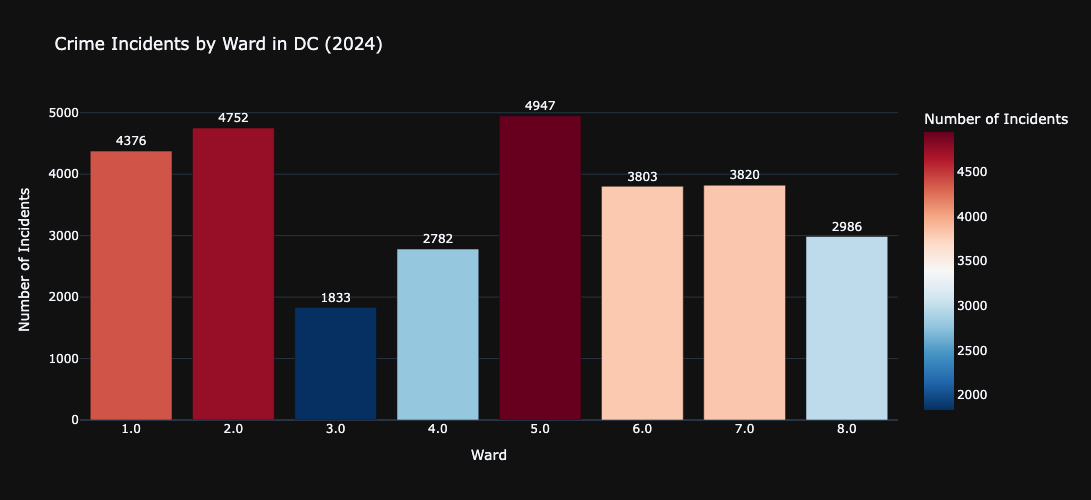

In [12]:
ward_counts = df['WARD'].value_counts().reset_index()
ward_counts.columns = ['Ward', 'Count']
ward_counts['Ward'] = ward_counts['Ward'].astype(str)
ward_counts = ward_counts.sort_values('Ward')

fig2 = px.bar(
    ward_counts,
    x='Ward',
    y='Count',
    title='Crime Incidents by Ward in DC (2024)',
    color='Count',
    color_continuous_scale='RdBu_r',
    labels={'Count': 'Number of Incidents'},
    template='plotly_dark',
    text='Count'
)
fig2.update_traces(textposition='outside')
fig2.update_layout(height=500)
fig2.show()

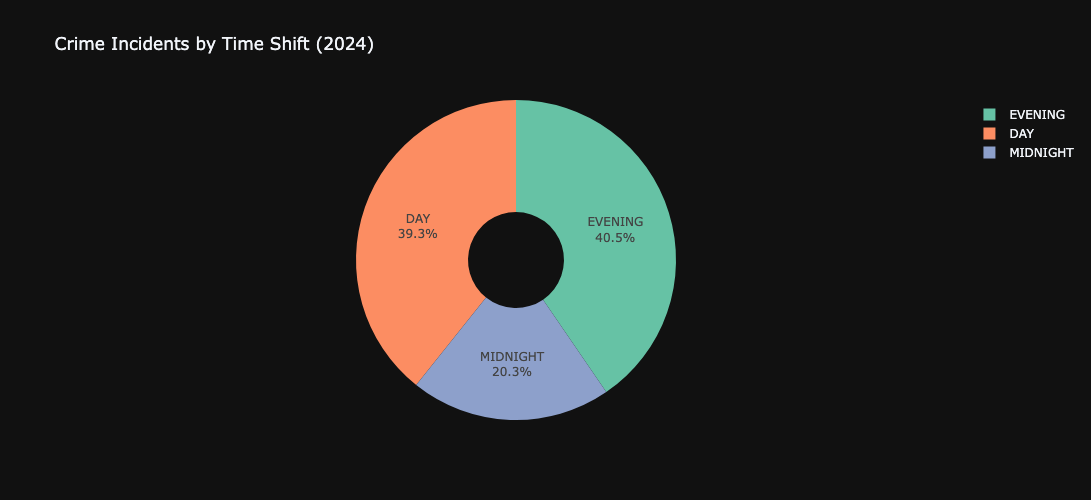

In [13]:
shift_counts = df['SHIFT'].value_counts().reset_index()
shift_counts.columns = ['Shift', 'Count']

fig3 = px.pie(
    shift_counts,
    names='Shift',
    values='Count',
    title='Crime Incidents by Time Shift (2024)',
    color_discrete_sequence=px.colors.qualitative.Set2,
    template='plotly_dark',
    hole=0.3
)
fig3.update_traces(textposition='inside', textinfo='percent+label')
fig3.update_layout(height=500)
fig3.show()

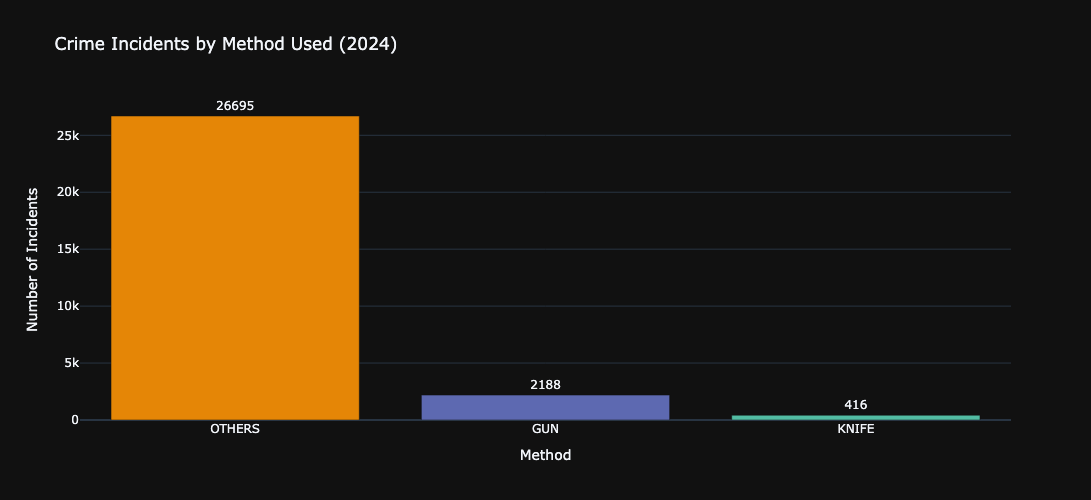

In [14]:
method_counts = df['METHOD'].value_counts().reset_index()
method_counts.columns = ['Method', 'Count']

fig4 = px.bar(
    method_counts,
    x='Method',
    y='Count',
    title='Crime Incidents by Method Used (2024)',
    color='Method',
    color_discrete_sequence=px.colors.qualitative.Vivid,
    labels={'Count': 'Number of Incidents'},
    template='plotly_dark',
    text='Count'
)
fig4.update_traces(textposition='outside')
fig4.update_layout(height=500, showlegend=False)
fig4.show()

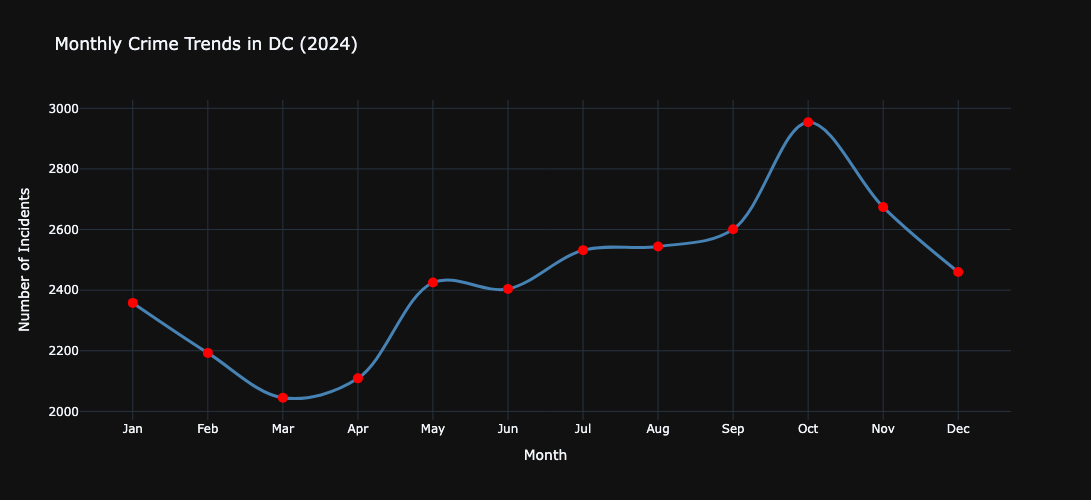

In [15]:
month_counts = df.groupby('MONTH').size().reset_index(name='COUNT')
month_names = ['Jan','Feb','Mar','Apr','May','Jun',
               'Jul','Aug','Sep','Oct','Nov','Dec']
month_counts['MONTH_LABEL'] = month_counts['MONTH'].apply(lambda x: month_names[x-1])

fig5 = px.line(
    month_counts,
    x='MONTH_LABEL',
    y='COUNT',
    title='Monthly Crime Trends in DC (2024)',
    markers=True,
    labels={'COUNT': 'Number of Incidents', 'MONTH_LABEL': 'Month'},
    template='plotly_dark',
    line_shape='spline'
)
fig5.update_traces(
    line=dict(color='steelblue', width=3),
    marker=dict(size=10, color='red')
)
fig5.update_layout(height=500)
fig5.show()

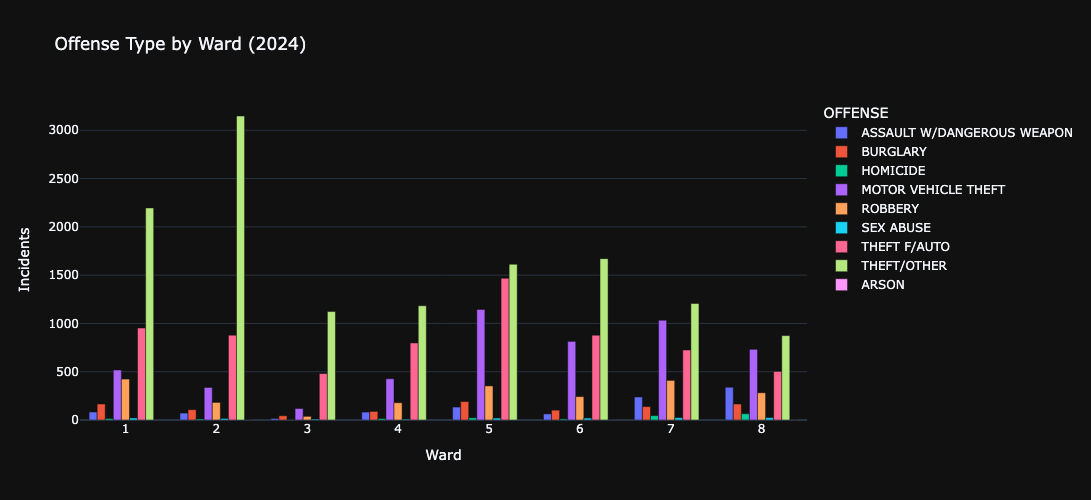

In [19]:
offense_ward = df.groupby(['WARD', 'OFFENSE']).size().reset_index(name='COUNT')
fig6 = px.bar(offense_ward, x='WARD', y='COUNT', color='OFFENSE',
              title='Offense Type by Ward (2024)', barmode='group',
              template='plotly_dark', labels={'COUNT':'Incidents','WARD':'Ward'})
fig6.update_layout(height=500)
fig6.show()

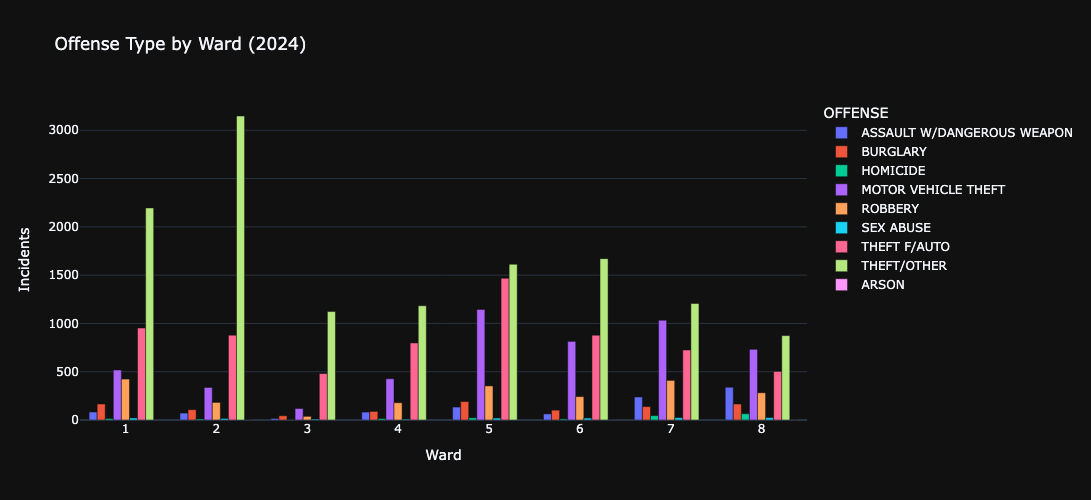

In [18]:
offense_ward = df.groupby(['WARD', 'OFFENSE']).size().reset_index(name='COUNT')
fig6 = px.bar(offense_ward, x='WARD', y='COUNT', color='OFFENSE',
              title='Offense Type by Ward (2024)', barmode='group',
              template='plotly_dark', labels={'COUNT':'Incidents','WARD':'Ward'})
fig6.update_layout(height=500)
fig6.show()

In [16]:
print('=== SUMMARY STATISTICS ===')
print(f'Total crime incidents: {len(df):,}')
print(f'Most common crime: {df["OFFENSE"].mode()[0]}')
print(f'Number of unique crime types: {df["OFFENSE"].nunique()}')
print(f'Ward with most incidents: Ward {df["WARD"].value_counts().idxmax()}')
print(f'Most dangerous shift: {df["SHIFT"].value_counts().idxmax()}')
print(f'Most common method: {df["METHOD"].value_counts().idxmax()}')

=== SUMMARY STATISTICS ===
Total crime incidents: 29,299
Most common crime: THEFT/OTHER
Number of unique crime types: 9
Ward with most incidents: Ward 5.0
Most dangerous shift: EVENING
Most common method: OTHERS
